<a href="https://colab.research.google.com/github/kimathivictormutwiri-prog/sports_analysis/blob/main/day1_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/sports_analysis
!git clone https://github.com/kimathivictormutwiri-prog/sports_analysis.git /content/sports_analysis
!ls /content/sports_analysis

Cloning into '/content/sports_analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), done.
README.md  sports_analysis


In [ ]:
import os
os.chdir('/content/sports_analysis/sports_analysis')
!pwd
!ls

/content/sports_analysis/sports_analysis
backend  README.md  requirements.txt  src


In [ ]:
!pip install -r requirements.txt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.4 MB/s eta 0:00:00


In [ ]:
import cv2
import ultralytics
import anthropic
import numpy as np

print(f"OpenCV: {cv2.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"NumPy: {np.__version__}")
print("✅ All packages installed successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
OpenCV: 4.13.0
Ultralytics: 8.4.67
NumPy: 2.0.2
✅ All packages installed successfully


In [ ]:
!nvidia-smi

Mon Jun 15 16:33:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

base = '/content/drive/MyDrive/sports_analysis_outputs'

folders = [
    f'{base}/frames',
    f'{base}/annotated',
    f'{base}/reports',
    f'{base}/heatmaps'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

✅ Created: /content/drive/MyDrive/sports_analysis_outputs/frames
✅ Created: /content/drive/MyDrive/sports_analysis_outputs/annotated
✅ Created: /content/drive/MyDrive/sports_analysis_outputs/reports
✅ Created: /content/drive/MyDrive/sports_analysis_outputs/heatmaps


In [ ]:
!cat /content/sports_analysis/sports_analysis/src/video_processor.py

import cv2
import os


class VideoProcessor:
    """Processes sports videos by extracting and preprocessing frames."""

    def __init__(self, video_path, output_dir, fps=5):
        """Initialize the processor with video path, output directory, and target fps."""
        self.video_path = video_path
        self.output_dir = output_dir
        self.fps = fps

    def get_video_info(self):
        """Return metadata about the video including duration, fps, and resolution."""
        cap = cv2.VideoCapture(self.video_path)
        if not cap.isOpened():
            raise ValueError(f"Could not open video file: {self.video_path}")

        original_fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration_seconds = total_frames / original_fps if original_fps else 0

        info = {
            "filename": os.path.basename(se

In [7]:
import importlib.util
import sys

spec = importlib.util.spec_from_file_location(
    "video_processor",
    "/content/sports_analysis/sports_analysis/src/video_processor.py"
)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
VideoProcessor = module.VideoProcessor

print("✅ Import successful")

FileNotFoundError: [Errno 2] No such file or directory: '/content/sports_analysis/sports_analysis/src/video_processor.py'

In [ ]:
!apt-get install -y ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
!ls '/content/drive/MyDrive/' | grep -i test

test_video.mov


In [ ]:
!ls '/content/drive/MyDrive/'

'Colab Notebooks'			 test_video.mov
'Project.Hail.Mary.null.en (1)-en.srt'	'Untitled document.gdoc'


In [4]:
!ffmpeg -i '/content/drive/MyDrive/test_video.mov' '/content/drive/MyDrive/test_video.mp4' -y

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [6]:
import cv2

video_path = '/content/drive/MyDrive/test_video.mp4'
output_dir = '/content/drive/MyDrive/sports_analysis_outputs/frames'

processor = VideoProcessor(video_path, output_dir, fps=5)

print("--- Video Info ---")
info = processor.get_video_info()

print("\n--- Extracting Frames ---")
total_saved = processor.extract_frames()
print(f"✅ Total frames saved: {total_saved}")

frame = cv2.imread(f"{output_dir}/frame_0001.jpg")
processed = processor.preprocess_frame(frame)
print(f"\n--- Preprocessed Frame Shape ---")
print(f"✅ Shape: {processed.shape}  (expected: (640, 640, 3))")

NameError: name 'VideoProcessor' is not defined

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Only clone if it doesn't already exist on Drive
repo_path = '/content/drive/MyDrive/sports_analysis'

if not os.path.exists(repo_path):
    !git clone https://github.com/kimathivictormutwiri-prog/sports_analysis.git {repo_path}
else:
    print("Repo already exists on Drive, pulling latest changes")
    os.chdir(repo_path)
    !git pull origin main

os.chdir(repo_path)
!pwd
!ls

Cloning into '/content/drive/MyDrive/sports_analysis'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 17 (delta 2), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), done.
Resolving deltas: 100% (2/2), done.
/content/drive/MyDrive/sports_analysis
README.md  sports_analysis


In [3]:
import os
os.chdir('/content/drive/MyDrive/sports_analysis')
!git pull origin main
!pip install -r requirements.txt -q

From https://github.com/kimathivictormutwiri-prog/sports_analysis
 * branch            main       -> FETCH_HEAD
Already up to date.
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [4]:
import os
os.chdir('/content/drive/MyDrive/sports_analysis')
print("Current directory:", os.getcwd())
!ls

Current directory: /content/drive/MyDrive/sports_analysis
README.md  sports_analysis


In [5]:
import os
os.chdir('/content/drive/MyDrive/sports_analysis/sports_analysis')
print("Current directory:", os.getcwd())
!ls

Current directory: /content/drive/MyDrive/sports_analysis/sports_analysis
backend  README.md  requirements.txt  src


In [6]:
!pip install -r requirements.txt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.9 MB/s eta 0:00:00


In [7]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "video_processor",
    "/content/drive/MyDrive/sports_analysis/sports_analysis/src/video_processor.py"
)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
VideoProcessor = module.VideoProcessor

print("✅ Import successful")

✅ Import successful


In [8]:
import cv2

video_path = '/content/drive/MyDrive/test_video.mp4'
output_dir = '/content/drive/MyDrive/sports_analysis_outputs/frames'

processor = VideoProcessor(video_path, output_dir, fps=5)

print("--- Video Info ---")
info = processor.get_video_info()

print("\n--- Extracting Frames ---")
total_saved = processor.extract_frames()
print(f"✅ Total frames saved: {total_saved}")

frame = cv2.imread(f"{output_dir}/frame_0001.jpg")
processed = processor.preprocess_frame(frame)
print(f"\n--- Preprocessed Frame Shape ---")
print(f"✅ Shape: {processed.shape}  (expected: (640, 640, 3))")

--- Video Info ---
filename: test_video.mp4
duration_seconds: 55.483333333333334
original_fps: 60.0
resolution: 2304x1026
total_frames: 3329

--- Extracting Frames ---
Saved 50 frames
Saved 100 frames
Saved 150 frames
Saved 200 frames
Saved 250 frames
✅ Total frames saved: 278


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [9]:
!ls /content/drive/MyDrive/sports_analysis_outputs/frames | head -10

ls: cannot access '/content/drive/MyDrive/sports_analysis_outputs/frames': No such file or directory


In [10]:
!ls /content/drive/MyDrive/sports_analysis_outputs

ls: cannot access '/content/drive/MyDrive/sports_analysis_outputs': No such file or directory


In [11]:
import os

base = '/content/drive/MyDrive/sports_analysis_outputs'

folders = [
    f'{base}/frames',
    f'{base}/annotated',
    f'{base}/reports',
    f'{base}/heatmaps'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

✅ Created: /content/drive/MyDrive/sports_analysis_outputs/frames
✅ Created: /content/drive/MyDrive/sports_analysis_outputs/annotated
✅ Created: /content/drive/MyDrive/sports_analysis_outputs/reports
✅ Created: /content/drive/MyDrive/sports_analysis_outputs/heatmaps


In [13]:
!find /content -name "frame_0001.jpg" 2>/dev/null
!find /content/drive -name "frame_0001.jpg" 2>/dev/null

In [14]:
total_saved = processor.extract_frames()
print(f"✅ Total frames saved: {total_saved}")

Saved 50 frames
Saved 100 frames
Saved 150 frames
Saved 200 frames
Saved 250 frames
✅ Total frames saved: 278


In [15]:
import cv2

frame = cv2.imread(f"{output_dir}/frame_0001.jpg")
processed = processor.preprocess_frame(frame)
print(f"✅ Shape: {processed.shape}  (expected: (640, 640, 3))")

✅ Shape: (640, 640, 3)  (expected: (640, 640, 3))


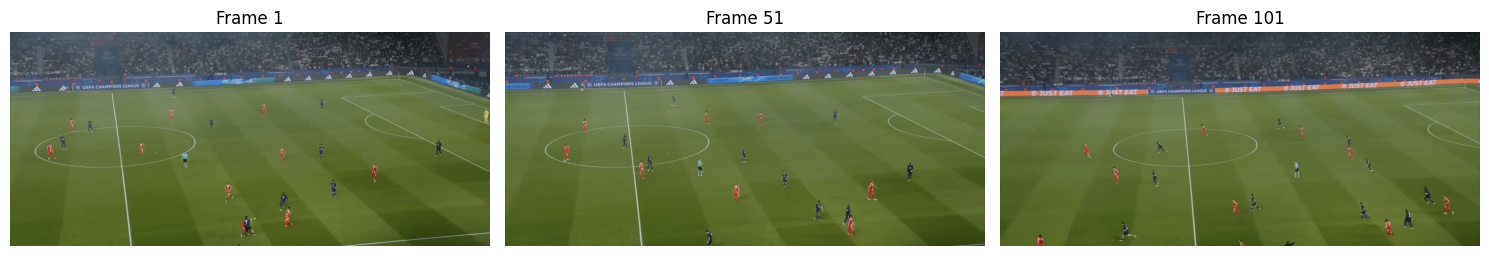

In [16]:
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    frame = cv2.imread(f"{output_dir}/frame_{(i*50)+1:04d}.jpg")
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(frame_rgb)
    ax.set_title(f"Frame {(i*50)+1}")
    ax.axis('off')
plt.tight_layout()
plt.show()